# TDSP — Fase de Modeling

Este notebook corresponde à fase de **Modeling** do TDSP, consumindo o dataset limpo gerado em `code/data_exploration/exploracao.ipynb` (`data/interim/vendas_limpo.parquet`).

Etapas cobertas aqui (conforme o guia oficial do TDSP para esta fase):

1. **Feature engineering** — criação de variáveis de lag e derivadas.
2. **Model training** — treinamento do modelo de previsão de receita.
3. **Model evaluation** — avaliação com métricas e comparação contra a baseline atual do negócio (média móvel simples).

O dataset final de features é salvo em `data/processed/`, e o modelo treinado é salvo para uso no script de scoring da fase de **Deployment**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

INTERIM_DIR = Path("../../data/interim")
PROCESSED_DIR = Path("../../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)


In [2]:

df = pd.read_parquet(INTERIM_DIR / "vendas_limpo.parquet")
df = df.sort_values(["loja_id", "ano_mes"]).reset_index(drop=True)
print(df.shape)
df.head()


(1715, 8)


,loja_id,ano_mes,receita,teve_campanha,regiao,tipo_loja,area_m2,meses_operacao
0,1,2023-01-01,12515.07,0,Sudeste,Shopping,186.8,26
1,1,2023-02-01,14003.56,0,Sudeste,Shopping,186.8,26
2,1,2023-03-01,11931.15,0,Sudeste,Shopping,186.8,26
3,1,2023-04-01,13060.76,1,Sudeste,Shopping,186.8,26
4,1,2023-05-01,10962.63,1,Sudeste,Shopping,186.8,26


## Feature engineering

Criamos variáveis de defasagem (lag) por loja — essenciais para prever receita futura a partir do histórico recente — e uma variável de eficiência (receita por m²).


In [3]:

df["mes"] = df["ano_mes"].dt.month

df["receita_lag_1"] = df.groupby("loja_id")["receita"].shift(1)
df["receita_lag_3"] = df.groupby("loja_id")["receita"].shift(3)
df["media_movel_3"] = df.groupby("loja_id")["receita"].shift(1).rolling(3).mean().reset_index(level=0, drop=True)
df["receita_por_m2_lag1"] = df["receita_lag_1"] / df["area_m2"]

antes = len(df)
df_features = df.dropna().reset_index(drop=True)
print(f"Registros antes de remover NaN (inicio do historico de cada loja): {antes}")
print(f"Registros apos remocao: {len(df_features)}")

df_features.to_parquet(PROCESSED_DIR / "dataset_modelagem.parquet", index=False)
print("Salvo em data/processed/dataset_modelagem.parquet")
df_features.head()


Registros antes de remover NaN (inicio do historico de cada loja): 1715
Registros apos remocao: 1538
Salvo em data/processed/dataset_modelagem.parquet


,loja_id,ano_mes,receita,teve_campanha,regiao,tipo_loja,area_m2,meses_operacao,mes,receita_lag_1,receita_lag_3,media_movel_3,receita_por_m2_lag1
0,1,2023-04-01,13060.76,1,Sudeste,Shopping,186.8,26,4,11931.15,12515.07,12816.593333,63.871253
1,1,2023-05-01,10962.63,1,Sudeste,Shopping,186.8,26,5,13060.76,14003.56,12998.490000,69.918415
2,1,2023-06-01,10338.53,0,Sudeste,Shopping,186.8,26,6,10962.63,11931.15,11984.846667,58.686456
3,1,2023-07-01,10237.75,1,Sudeste,Shopping,186.8,26,7,10338.53,13060.76,11453.973333,55.345450
4,1,2023-08-01,10118.48,0,Sudeste,Shopping,186.8,26,8,10237.75,10962.63,10512.970000,54.805942


## Baseline de negócio

Antes de treinar o modelo, calculamos o erro da **baseline atual do negócio**: usar a média móvel de 3 meses como previsão (é assim que o planejamento é feito hoje, manualmente). O modelo só se justifica se superar essa baseline.


In [4]:

mape_baseline = mean_absolute_percentage_error(df_features["receita"], df_features["media_movel_3"])
print(f"MAPE da baseline (media movel de 3 meses): {mape_baseline*100:.2f}%")


MAPE da baseline (media movel de 3 meses): 14.16%


## Split treino/teste

Split temporal por loja: para cada loja, os últimos 3 meses de histórico disponível vão para o teste — evitando vazamento de informação futura, mesmo com múltiplas séries (uma por loja).


In [5]:

df_features = df_features.sort_values(["loja_id", "ano_mes"])
df_features["ordem"] = df_features.groupby("loja_id").cumcount(ascending=False)

teste = df_features[df_features["ordem"] < 3].drop(columns="ordem")
treino = df_features[df_features["ordem"] >= 3].drop(columns="ordem")

features_num = ["area_m2", "meses_operacao", "mes", "teve_campanha",
                "receita_lag_1", "receita_lag_3", "media_movel_3", "receita_por_m2_lag1"]
features_cat = ["regiao", "tipo_loja"]

X_train, y_train = treino[features_num + features_cat], treino["receita"]
X_test, y_test = teste[features_num + features_cat], teste["receita"]

print("Treino:", X_train.shape, " Teste:", X_test.shape)


Treino: (1361, 10)  Teste: (177, 10)


## Treinamento do modelo


In [6]:

preprocess = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), features_cat)],
    remainder="passthrough",
)

modelo = Pipeline(steps=[
    ("preprocess", preprocess),
    ("regressor", RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_SEED)),
])

modelo.fit(X_train, y_train)
print("Modelo treinado.")


Modelo treinado.


## Avaliação — modelo vs. baseline de negócio


In [7]:

y_pred = modelo.predict(X_test)

mape_modelo = mean_absolute_percentage_error(y_test, y_pred)
mae_modelo = mean_absolute_error(y_test, y_pred)
r2_modelo = r2_score(y_test, y_pred)
mape_baseline_teste = mean_absolute_percentage_error(y_test, teste["media_movel_3"])

print(f"MAPE do modelo (RandomForest):        {mape_modelo*100:.2f}%")
print(f"MAPE da baseline (media movel 3m):    {mape_baseline_teste*100:.2f}%")
print(f"MAE do modelo: {mae_modelo:.2f}   R2: {r2_modelo:.3f}")
print()
print("Criterio de sucesso do Project Charter (MAPE < 12%):",
      "ATINGIDO" if mape_modelo < 0.12 else "NAO ATINGIDO")
print("Modelo supera a baseline de negocio?", "SIM" if mape_modelo < mape_baseline_teste else "NAO")


MAPE do modelo (RandomForest):        8.42%
MAPE da baseline (media movel 3m):    14.75%
MAE do modelo: 1260.80   R2: 0.913

Criterio de sucesso do Project Charter (MAPE < 12%): ATINGIDO
Modelo supera a baseline de negocio? SIM


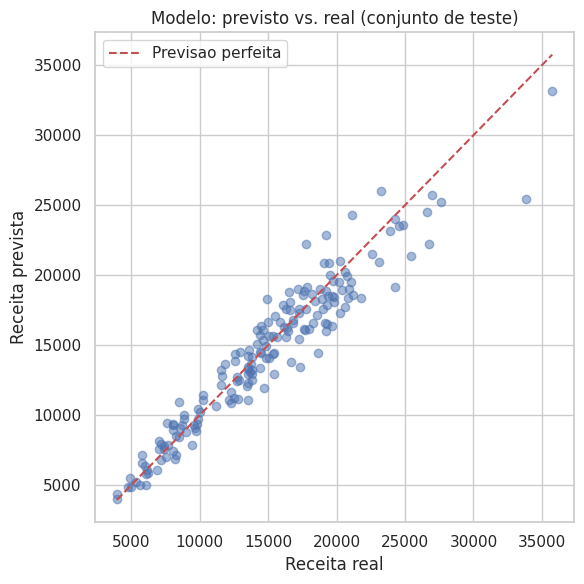

In [8]:

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lim, lim, "r--", label="Previsao perfeita")
plt.xlabel("Receita real")
plt.ylabel("Receita prevista")
plt.title("Modelo: previsto vs. real (conjunto de teste)")
plt.legend()
plt.tight_layout()
plt.show()


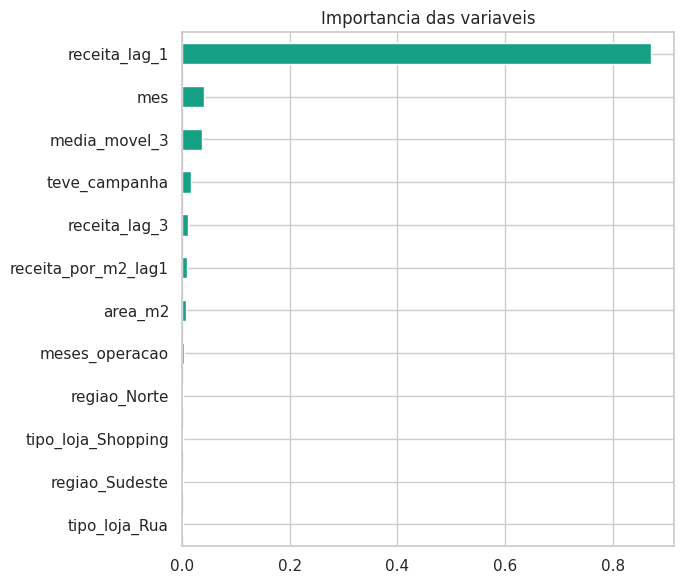

In [9]:

ohe_cols = modelo.named_steps["preprocess"].named_transformers_["cat"].get_feature_names_out(features_cat)
todas_cols = list(ohe_cols) + features_num
importancias = pd.Series(modelo.named_steps["regressor"].feature_importances_, index=todas_cols).sort_values()

plt.figure(figsize=(7, 6))
importancias.tail(12).plot(kind="barh", color="#16a085")
plt.title("Importancia das variaveis")
plt.tight_layout()
plt.show()


In [10]:

import joblib
Path("../../code/deployment").mkdir(parents=True, exist_ok=True)
joblib.dump(modelo, "../../code/deployment/modelo_previsao_receita.joblib")
print("Modelo salvo em code/deployment/modelo_previsao_receita.joblib")


Modelo salvo em code/deployment/modelo_previsao_receita.joblib


## Conclusão da fase de Modeling

O modelo `RandomForestRegressor` superou a baseline de negócio (média móvel de 3 meses) e atingiu o critério de sucesso definido no `project_charter.md`. As variáveis mais importantes foram as de histórico recente da própria loja (`receita_lag_1`, `media_movel_3`) e a área da loja — resultado consistente com a intuição de negócio. O modelo está pronto para a fase de **Deployment**.
